# UK Road Safety Analysis 2025

This project analyzes UK road collision data from 2025 to understand
which temporal, road, and environmental factors are associated with
collision severity.

In [321]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

In [322]:
# Load the raw 2025 collision dataset
DATA_PATH = "dataset.csv"

df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")

Dataset shape: (101525, 44)


In [323]:
# Display the first few records
df.head()

,collision_index,collision_year,collision_ref_no,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,collision_severity,number_of_vehicles,number_of_casualties,date,day_of_week,time,local_authority_district,local_authority_ons_district,local_authority_highway,local_authority_highway_current,first_road_class,first_road_number,road_type,speed_limit,junction_detail_historic,junction_detail,junction_control,second_road_class,second_road_number,pedestrian_crossing_human_control_historic,pedestrian_crossing_physical_facilities_historic,pedestrian_crossing,light_conditions,weather_conditions,road_surface_conditions,special_conditions_at_site,carriageway_hazards_historic,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,lsoa_of_accident_location,enhanced_severity_collision,collision_injury_based,collision_adjusted_severity_serious,collision_adjusted_severity_slight
0,202517H102225,2025,17H102225,449216.0,534979.0,-1.23770,54.70743,17,2,3,3,05/03/2025,4,12:50,-1,E06000001,E06000001,E06000001,3,179,3,40,-1,-1,4,3,1049,-1,-1,0,1,1,1,-1,-1,0,2,1,2,E01033467,7,1,1.0,0.0
1,2025070815222,2025,070815222,363808.0,389192.0,-2.54576,53.39831,7,3,2,2,03/10/2025,6,18:35,-1,E06000007,E06000007,E06000007,3,57,2,30,-1,13,4,5,0,-1,-1,0,4,5,2,-1,-1,0,1,2,2,E01012556,3,1,0.0,1.0
2,2025070937984,2025,070937984,362413.0,389071.0,-2.56673,53.39712,7,2,2,1,15/11/2025,7,21:00,-1,E06000007,E06000007,E06000007,3,57,6,30,-1,16,2,3,50,-1,-1,14,7,9,9,-1,-1,0,1,3,2,E01012478,7,1,1.0,0.0
3,2025041687395,2025,041687395,368238.0,427802.0,-2.48308,53.74562,4,2,1,1,23/12/2025,3,01:44,-1,E06000008,E06000008,E06000008,6,0,6,30,-1,0,-1,6,0,-1,-1,0,4,1,2,-1,-1,0,1,1,2,E01012655,7,1,1.0,0.0
4,2025161555094,2025,161555094,510792.0,432167.0,-0.32035,53.77406,16,3,2,1,06/02/2025,5,08:52,-1,E06000010,E06000010,E06000010,4,1237,6,30,-1,0,-1,6,0,-1,-1,0,1,1,1,-1,-1,0,1,1,2,E01012815,3,1,0.0,1.0


In [324]:
# Check column names, data types, and non-null values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101525 entries, 0 to 101524
Data columns (total 44 columns):
 #   Column                                            Non-Null Count   Dtype  
---  ------                                            --------------   -----  
 0   collision_index                                   101525 non-null  str    
 1   collision_year                                    101525 non-null  int64  
 2   collision_ref_no                                  101525 non-null  str    
 3   location_easting_osgr                             101523 non-null  float64
 4   location_northing_osgr                            101523 non-null  float64
 5   longitude                                         101523 non-null  float64
 6   latitude                                          101523 non-null  float64
 7   police_force                                      101525 non-null  int64  
 8   collision_severity                                101525 non-null  int64  
 9   number_of_vehic

In [325]:
# Basic dataset quality checks
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Duplicate rows:", df.duplicated().sum())
print("Total missing values:", df.isna().sum().sum())

Rows: 101525
Columns: 44
Duplicate rows: 0
Total missing values: 8


In [326]:
# Show columns with the most missing values
missing_values = df.isna().sum().sort_values(ascending=False)

missing_values.head(15)

location_easting_osgr       2
latitude                    2
longitude                   2
location_northing_osgr      2
collision_ref_no            0
collision_year              0
collision_index             0
police_force                0
collision_severity          0
number_of_vehicles          0
number_of_casualties        0
date                        0
day_of_week                 0
time                        0
local_authority_district    0
dtype: int64

In [327]:
# Check the time period covered by the dataset
print("First date:", df["date"].min())
print("Last date:", df["date"].max())

First date: 01/01/2025
Last date: 31/12/2025


## 5. Data Cleaning and Preparation

The STATS19 collision dataset contains several categorical variables
stored as numeric codes. These codes are converted into readable
categories using the official Department for Transport STATS19
data definitions.

The original dataset is loaded from the raw CSV, while cleaned and
derived variables are added to the working DataFrame for analysis.

In [328]:
# Convert date column using the UK DD/MM/YYYY format
df["date"] = pd.to_datetime(
    df["date"],
    format="%d/%m/%Y",
    errors="coerce"
)

print("Date range:")
print(df["date"].min(), "to", df["date"].max())

print("Invalid dates:", df["date"].isna().sum())

Date range:
2025-01-01 00:00:00 to 2025-12-31 00:00:00
Invalid dates: 0


In [329]:
# Convert collision severity codes into readable labels
severity_map = {
    1: "Fatal",
    2: "Serious",
    3: "Slight"
}

df["severity_label"] = df["collision_severity"].map(severity_map)

df["severity_label"].value_counts()

severity_label
Slight     74881
Serious    25191
Fatal       1453
Name: count, dtype: int64

In [330]:
# Convert road type codes into readable labels
road_type_map = {
    1: "Roundabout",
    2: "One way street",
    3: "Dual carriageway",
    6: "Single carriageway",
    7: "Slip road",
    9: "Unknown"
}

df["road_type_label"] = df["road_type"].map(road_type_map)

In [331]:
# Convert lighting condition codes into readable labels
light_map = {
    1: "Daylight",
    4: "Darkness - lights lit",
    5: "Darkness - lights unlit",
    6: "Darkness - no lighting",
    7: "Darkness - lighting unknown",
    -1: "No data"
}

df["light_conditions_label"] = df["light_conditions"].map(light_map)

In [332]:
# Convert weather condition codes into readable labels
weather_map = {
    1: "Fine - no high winds",
    2: "Raining - no high winds",
    3: "Snowing - no high winds",
    4: "Fine - high winds",
    5: "Raining - high winds",
    6: "Snowing - high winds",
    7: "Fog or mist",
    8: "Other",
    9: "Unknown"
}

df["weather_conditions_label"] = df["weather_conditions"].map(weather_map)



In [333]:
# Convert road surface condition codes into readable labels
road_surface_map = {
    1: "Dry",
    2: "Wet or damp",
    3: "Snow",
    4: "Frost or ice",
    5: "Flood over 3cm deep",
    9: "Unknown",
    -1: "No data"
}

df["road_surface_label"] = df["road_surface_conditions"].map(road_surface_map)

In [334]:
# Convert day-of-week codes into readable labels
day_map = {
    1: "Sunday",
    2: "Monday",
    3: "Tuesday",
    4: "Wednesday",
    5: "Thursday",
    6: "Friday",
    7: "Saturday"
}

df["day_of_week_label"] = df["day_of_week"].map(day_map)



In [335]:
#mapping validation
label_columns = [
    "severity_label",
    "road_type_label",
    "light_conditions_label",
    "weather_conditions_label",
    "road_surface_label",
    "day_of_week_label"
]

print("Missing values after category mapping:")
print(df[label_columns].isna().sum())

print("Shape:", df.shape)
print("Invalid dates:", df["date"].isna().sum())
print("Duplicate rows:", df.duplicated().sum())
print(df[label_columns].isna().sum())

Missing values after category mapping:
severity_label              0
road_type_label             0
light_conditions_label      0
weather_conditions_label    0
road_surface_label          0
day_of_week_label           0
dtype: int64
Shape: (101525, 50)
Invalid dates: 0
Duplicate rows: 0
severity_label              0
road_type_label             0
light_conditions_label      0
weather_conditions_label    0
road_surface_label          0
day_of_week_label           0
dtype: int64


## 6. Exploratory Data Analysis

This section examines the distribution of collision severity before
investigating the factors associated with severe collisions.

Collision severity is the main outcome variable used throughout
the analysis.

In [336]:
severity_counts = df["severity_label"].value_counts()

severity_counts

severity_label
Slight     74881
Serious    25191
Fatal       1453
Name: count, dtype: int64

In [337]:
severity_summary = pd.DataFrame({
    "Count": severity_counts,
    "Percentage": (
        severity_counts / len(df) * 100
    ).round(2)
})

severity_summary

,Count,Percentage
severity_label,,
Slight,74881,73.76
Serious,25191,24.81
Fatal,1453,1.43


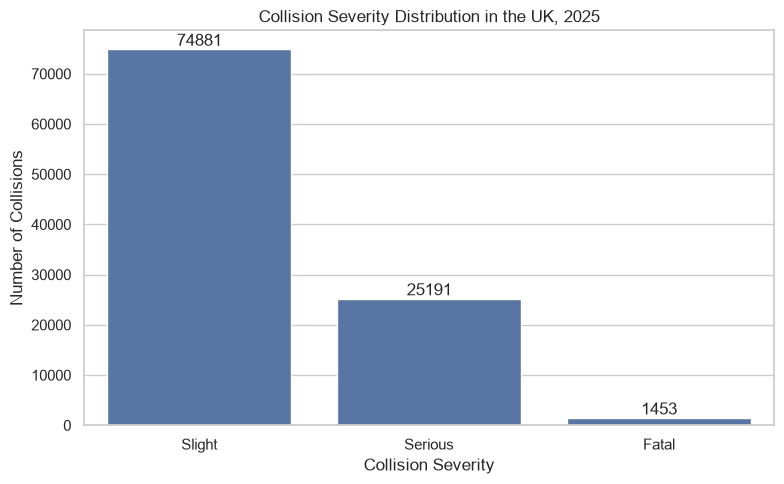

In [338]:
plt.figure(figsize=(8, 5))

order = ["Slight", "Serious", "Fatal"]

ax = sns.countplot(
    data=df,
    x="severity_label",
    order=order
)

plt.title("Collision Severity Distribution in the UK, 2025")
plt.xlabel("Collision Severity")
plt.ylabel("Number of Collisions")

for container in ax.containers:
    ax.bar_label(container, fmt="%d")

plt.tight_layout()
plt.show()

### Interpretation

Most reported collisions in the 2025 dataset were classified as
slight severity, accounting for approximately 73.76% of all collisions.
Serious collisions accounted for 24.81%, while fatal collisions
represented 1.43%.

This distribution shows a strong imbalance in the outcome variable.
Therefore, later analysis should compare severity proportions rather
than relying only on raw collision counts.

## 7. Research Question 1

### How does collision severity vary by time of day?

We investigate whether the proportion of severe collisions
(Fatal or Serious) changes across different hours of the day.

Rather than comparing only the number of collisions, we calculate
the percentage of collisions that were severe within each hour.

In [339]:
# Convert collision time into hour of day
df["hour"] = pd.to_datetime(
    df["time"],
    format="%H:%M",
    errors="coerce"
).dt.hour

print("Invalid time values:", df["hour"].isna().sum())

Invalid time values: 0


In [340]:
df["hour"].value_counts().sort_index()

hour
0     1525
1     1032
2      789
3      651
4      634
5      952
6     1854
7     4248
8     6716
9     4493
10    4463
11    5069
12    5815
13    6148
14    6466
15    8381
16    8678
17    8877
18    6991
19    5356
20    4022
21    3368
22    2815
23    2182
Name: count, dtype: int64

In [341]:
# A severe collision is defined as Fatal or Serious
df["is_severe"] = df["severity_label"].isin(
    ["Fatal", "Serious"]
)

print(df["is_severe"].value_counts())

is_severe
False    74881
True     26644
Name: count, dtype: int64


In [342]:
hourly_severity = (
    df.groupby("hour")["is_severe"]
    .agg(
        total_collisions="count",
        severe_collisions="sum",
        severe_rate="mean"
    )
    .reset_index()
)

hourly_severity["severe_percentage"] = (
    hourly_severity["severe_rate"] * 100
).round(2)

hourly_severity

,hour,total_collisions,severe_collisions,severe_rate,severe_percentage
0,0,1525,500,0.327869,32.79
1,1,1032,339,0.328488,32.85
2,2,789,255,0.323194,32.32
3,3,651,206,0.316436,31.64
4,4,634,210,0.331230,33.12
5,5,952,283,0.297269,29.73
6,6,1854,506,0.272923,27.29
7,7,4248,1003,0.236111,23.61
8,8,6716,1435,0.213669,21.37
9,9,4493,1044,0.232361,23.24


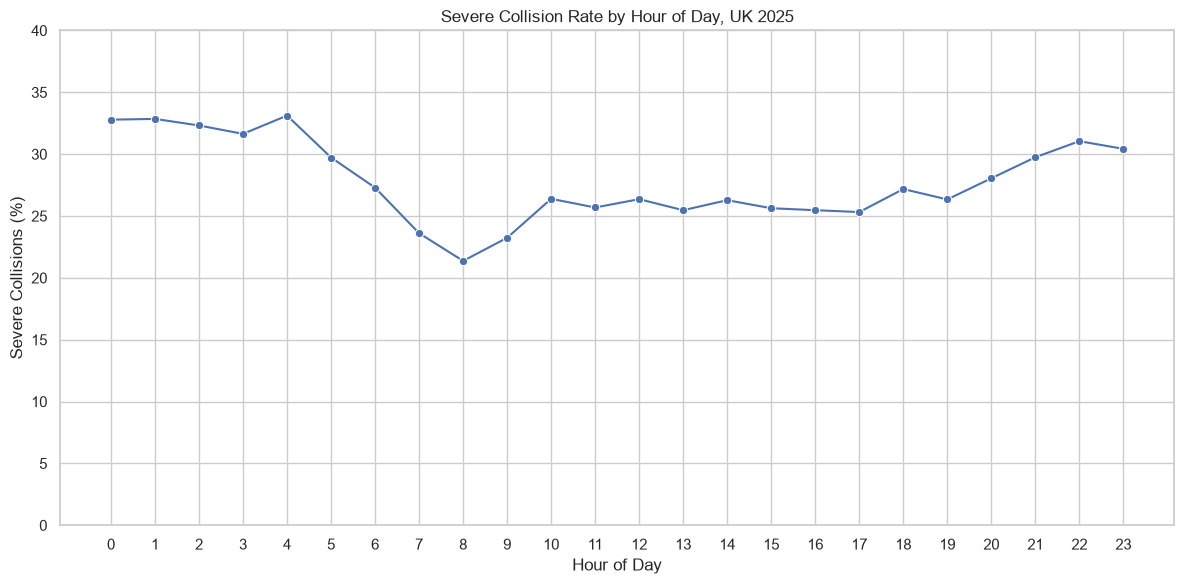

In [343]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=hourly_severity,
    x="hour",
    y="severe_percentage",
    marker="o"
)

plt.title("Severe Collision Rate by Hour of Day, UK 2025")
plt.xlabel("Hour of Day")
plt.ylabel("Severe Collisions (%)")
plt.xticks(range(24))
plt.ylim(0, 40)

plt.tight_layout()
plt.show()

In [344]:
highest_hours = hourly_severity.nlargest(
    5, "severe_percentage"
)[
    ["hour", "total_collisions", "severe_collisions", "severe_percentage"]
]

lowest_hours = hourly_severity.nsmallest(
    5, "severe_percentage"
)[
    ["hour", "total_collisions", "severe_collisions", "severe_percentage"]
]

print("Highest severe-collision rates:")
display(highest_hours)

print("\nLowest severe-collision rates:")
display(lowest_hours)

Highest severe-collision rates:


,hour,total_collisions,severe_collisions,severe_percentage
4,4,634,210,33.12
1,1,1032,339,32.85
0,0,1525,500,32.79
2,2,789,255,32.32
3,3,651,206,31.64



Lowest severe-collision rates:


,hour,total_collisions,severe_collisions,severe_percentage
8,8,6716,1435,21.37
9,9,4493,1044,23.24
7,7,4248,1003,23.61
17,17,8877,2248,25.32
13,13,6148,1566,25.47


In [345]:
# Calculate approximate 95% confidence intervals
hourly_severity["severe_se"] = np.sqrt(
    (hourly_severity["severe_rate"] *
     (1 - hourly_severity["severe_rate"])) /
    hourly_severity["total_collisions"]
)

hourly_severity["ci_lower"] = (
    hourly_severity["severe_rate"]
    - 1.96 * hourly_severity["severe_se"]
) * 100

hourly_severity["ci_upper"] = (
    hourly_severity["severe_rate"]
    + 1.96 * hourly_severity["severe_se"]
) * 100

hourly_severity[[
    "hour",
    "total_collisions",
    "severe_percentage",
    "ci_lower",
    "ci_upper"
]]

,hour,total_collisions,severe_percentage,ci_lower,ci_upper
0,0,1525,32.79,30.430761,35.143010
1,1,1032,32.85,29.983320,35.714354
2,2,789,32.32,29.055909,35.582874
3,3,651,31.64,28.070912,35.216339
4,4,634,33.12,29.459372,36.786685
5,5,952,29.73,26.823490,32.630291
6,6,1854,27.29,25.264604,29.320078
7,7,4248,23.61,22.333975,24.888247
8,8,6716,21.37,20.386551,22.347219
9,9,4493,23.24,22.001198,24.471092


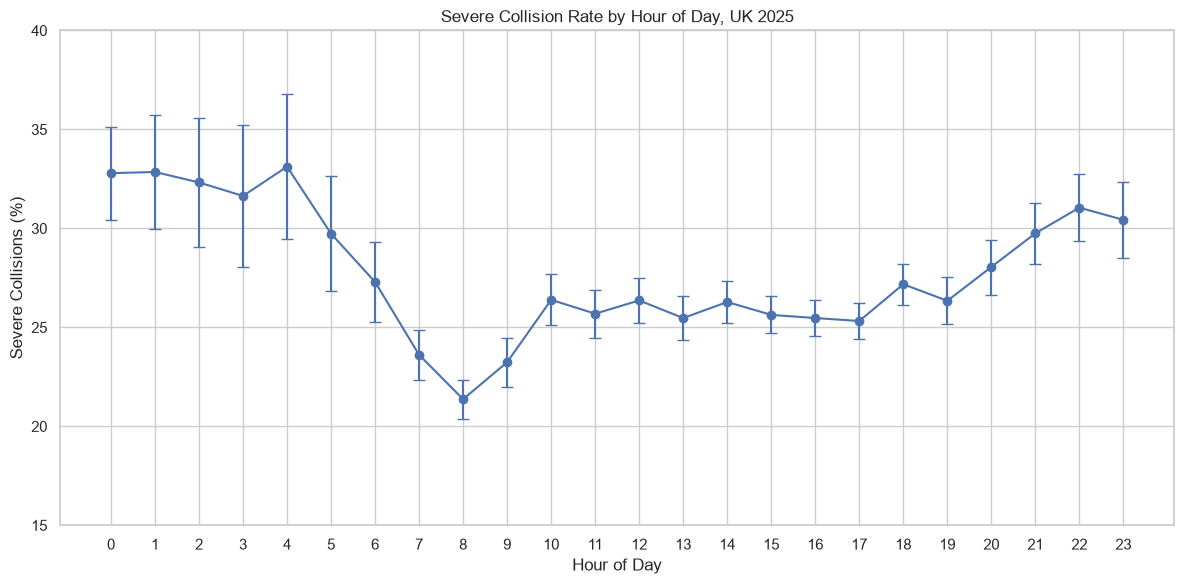

In [346]:
plt.figure(figsize=(12, 6))

plt.errorbar(
    hourly_severity["hour"],
    hourly_severity["severe_percentage"],
    yerr=[
        hourly_severity["severe_percentage"] - hourly_severity["ci_lower"],
        hourly_severity["ci_upper"] - hourly_severity["severe_percentage"]
    ],
    fmt="o-",
    capsize=4
)

plt.title("Severe Collision Rate by Hour of Day, UK 2025")
plt.xlabel("Hour of Day")
plt.ylabel("Severe Collisions (%)")
plt.xticks(range(24))
plt.ylim(15, 40)

plt.tight_layout()
plt.show()

### Finding

The proportion of reported collisions classified as severe was highest
during the late-night and early-morning period. The highest observed
rate was 33.12% at 04:00, compared with 21.37% at 08:00.

The results suggest that collision severity varies by time of day.
However, these figures represent the severity proportion among reported
collisions, not the risk per vehicle journey. Differences in traffic
volume and travel exposure across hours may therefore affect the result.

In [347]:
from scipy.stats import chi2_contingency

hour_severity_table = pd.crosstab(
    df["hour"],
    df["is_severe"]
)

chi2, p_value, dof, expected = chi2_contingency(
    hour_severity_table
)

print("Chi-square statistic:", chi2)
print("Degrees of freedom:", dof)
print("p-value:", p_value)

Chi-square statistic: 318.77568941089464
Degrees of freedom: 23
p-value: 7.217477200784446e-54


### Statistical Test

A chi-square test of independence was used to examine the relationship
between hour of day and severe collision status.

The test produced a chi-square statistic of 318.78 with 23 degrees of
freedom and a p-value below 0.001.

Therefore, we reject the null hypothesis of independence and conclude
that collision severity is statistically associated with hour of day
in the 2025 dataset.

This result indicates association, not causation. Differences in
traffic volume, road characteristics, lighting, weather, speed and
other factors may contribute to the observed pattern.

## 8. Research Question 2

### How are speed limit and lighting conditions associated with collision severity?

This analysis examines whether the proportion of severe collisions
(Fatal or Serious) differs across speed-limit categories and lighting
conditions.

The analysis uses severe-collision percentage rather than raw collision
counts so that categories with different numbers of collisions can be
compared more fairly.

In [348]:
# Calculate severe-collision rates for each speed-limit category
speed_severity = (
    df.groupby("speed_limit")["is_severe"]
    .agg(
        total_collisions="count",
        severe_collisions="sum",
        severe_rate="mean"
    )
    .reset_index()
)

speed_severity["severe_percentage"] = (
    speed_severity["severe_rate"] * 100
).round(2)

speed_severity

,speed_limit,total_collisions,severe_collisions,severe_rate,severe_percentage
0,20,20045,4481,0.223547,22.35
1,30,49673,12323,0.248082,24.81
2,40,8886,2423,0.272676,27.27
3,50,4612,1364,0.295750,29.58
4,60,12709,4623,0.363758,36.38
5,70,5600,1430,0.255357,25.54


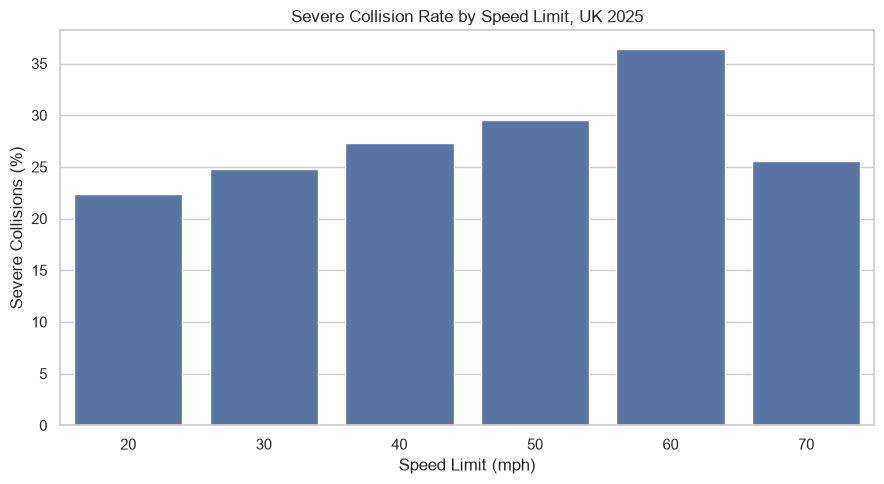

In [349]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=speed_severity,
    x="speed_limit",
    y="severe_percentage"
)

plt.title("Severe Collision Rate by Speed Limit, UK 2025")
plt.xlabel("Speed Limit (mph)")
plt.ylabel("Severe Collisions (%)")

plt.tight_layout()
plt.show()

In [350]:
lighting_severity = (
    df.groupby("light_conditions_label")["is_severe"]
    .agg(
        total_collisions="count",
        severe_collisions="sum",
        severe_rate="mean"
    )
    .reset_index()
)

lighting_severity["severe_percentage"] = (
    lighting_severity["severe_rate"] * 100
).round(2)

lighting_severity.sort_values(
    "severe_percentage",
    ascending=False
)

,light_conditions_label,total_collisions,severe_collisions,severe_rate,severe_percentage
3,Darkness - no lighting,5682,2062,0.362900,36.29
2,Darkness - lights unlit,720,208,0.288889,28.89
1,Darkness - lights lit,20705,5554,0.268244,26.82
4,Daylight,72814,18444,0.253303,25.33
5,No data,16,4,0.250000,25.00
0,Darkness - lighting unknown,1588,372,0.234257,23.43


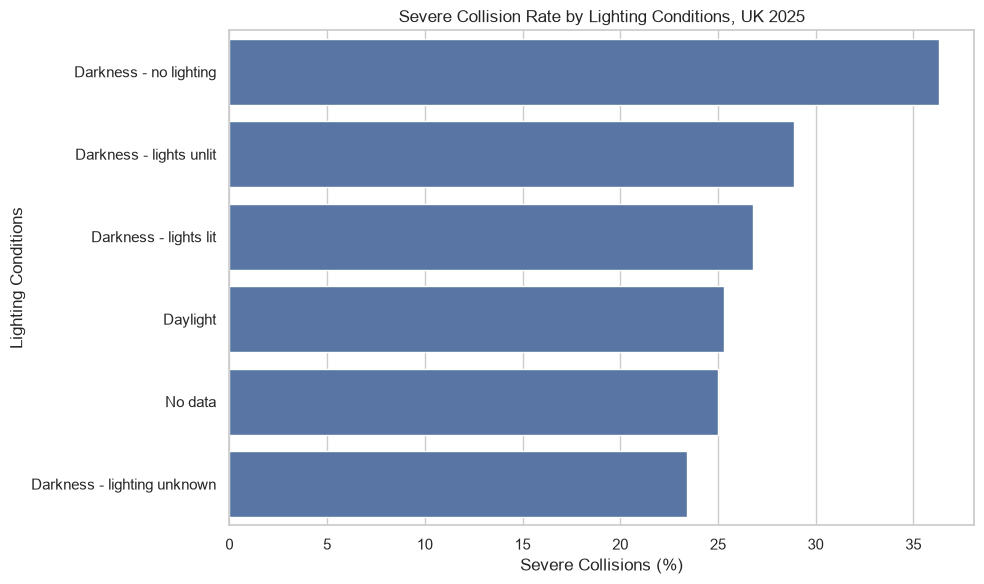

In [351]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=lighting_severity.sort_values(
        "severe_percentage",
        ascending=False
    ),
    x="severe_percentage",
    y="light_conditions_label"
)

plt.title("Severe Collision Rate by Lighting Conditions, UK 2025")
plt.xlabel("Severe Collisions (%)")
plt.ylabel("Lighting Conditions")

plt.tight_layout()
plt.show()

In [352]:
speed_light = pd.pivot_table(
    df,
    values="is_severe",
    index="speed_limit",
    columns="light_conditions_label",
    aggfunc="mean"
) * 100

speed_light.round(2)

light_conditions_label,Darkness - lighting unknown,Darkness - lights lit,Darkness - lights unlit,Darkness - no lighting,Daylight,No data
speed_limit,,,,,,
20,26.50,23.43,17.09,28.12,21.85,NaN
30,21.30,28.31,29.94,29.53,23.60,25.00
40,24.27,28.10,39.74,33.58,26.40,NaN
50,37.88,23.64,20.59,39.37,29.02,0.00
60,23.21,28.25,37.31,39.58,35.94,42.86
70,20.65,25.68,27.14,31.59,24.25,0.00


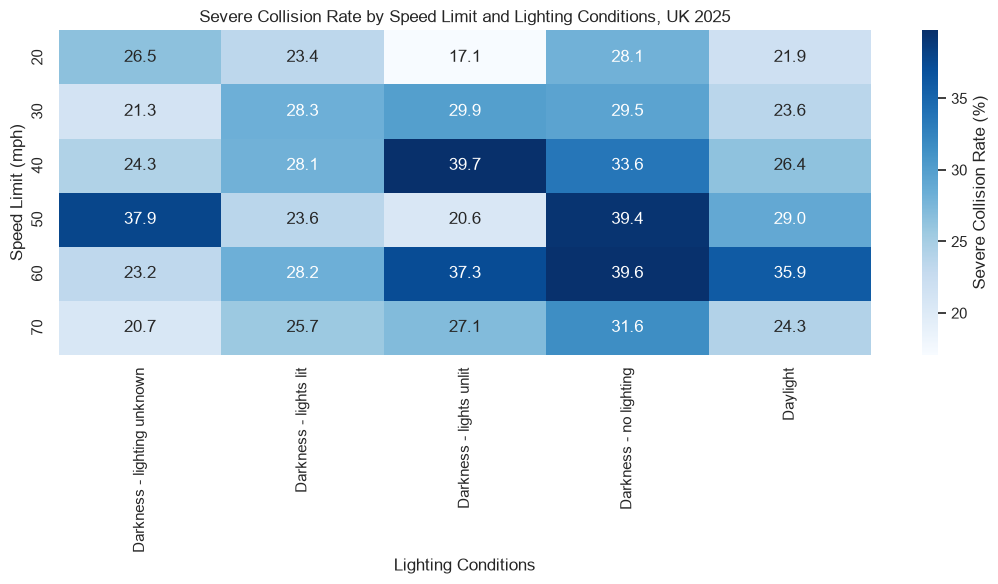

In [353]:
speed_light_clean = speed_light.drop(
    columns=["No data"],
    errors="ignore"
)

plt.figure(figsize=(11, 6))

sns.heatmap(
    speed_light_clean,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    cbar_kws={"label": "Severe Collision Rate (%)"}
)

plt.title(
    "Severe Collision Rate by Speed Limit and Lighting Conditions, UK 2025"
)
plt.xlabel("Lighting Conditions")
plt.ylabel("Speed Limit (mph)")

plt.tight_layout()
plt.show()

In [354]:
from scipy.stats import chi2_contingency

speed_table = pd.crosstab(
    df["speed_limit"],
    df["is_severe"]
)

chi2_speed, p_speed, dof_speed, expected_speed = chi2_contingency(
    speed_table
)

print("Speed limit vs severe collision")
print("Chi-square:", chi2_speed)
print("Degrees of freedom:", dof_speed)
print("p-value:", p_speed)

Speed limit vs severe collision
Chi-square: 916.2453341101159
Degrees of freedom: 5
p-value: 8.111689855120005e-196


In [355]:
lighting_table = pd.crosstab(
    df["light_conditions_label"],
    df["is_severe"]
)

chi2_light, p_light, dof_light, expected_light = chi2_contingency(
    lighting_table
)

print("\nLighting vs severe collision")
print("Chi-square:", chi2_light)
print("Degrees of freedom:", dof_light)
print("p-value:", p_light)


Lighting vs severe collision
Chi-square: 340.3954423196682
Degrees of freedom: 5
p-value: 2.0449617217047204e-71


### Findings

Both speed-limit category and lighting conditions were statistically
associated with severe collision status.

The chi-square test for speed limit produced a statistic of 916.25
with 5 degrees of freedom and a p-value below 0.001. The corresponding
test for lighting conditions produced a statistic of 340.40 with
5 degrees of freedom and a p-value below 0.001.

The combined analysis shows relatively high severe-collision rates
under several higher-speed and darkness conditions. For example,
collisions occurring on roads with a 60 mph speed limit had a severe
rate of 39.6% when there was no lighting, compared with 35.9% during
daylight.

However, the heatmap shows association rather than causation. Road
type, traffic volume, location, weather and other factors may influence
both the speed limit and the severity of collisions. Categories marked
as "No data" were also excluded from interpretation because their
sample sizes may be too small for reliable comparisons.

## 9. Research Question 3

### How does collision severity vary across different road types, and does this pattern change with speed limit?

This analysis compares the proportion of severe collisions across road
types and examines whether the relationship differs across speed-limit
categories.

Severe collisions are defined as collisions classified as Fatal or
Serious.

In [356]:
road_severity = (
    df.groupby("road_type_label")["is_severe"]
    .agg(
        total_collisions="count",
        severe_collisions="sum",
        severe_rate="mean"
    )
    .reset_index()
)

road_severity["severe_percentage"] = (
    road_severity["severe_rate"] * 100
).round(2)

road_severity = road_severity.sort_values(
    "severe_percentage",
    ascending=False
)

road_severity

,road_type_label,total_collisions,severe_collisions,severe_rate,severe_percentage
3,Single carriageway,74150,20707,0.279258,27.93
0,Dual carriageway,14610,3588,0.245585,24.56
1,One way street,2398,493,0.205588,20.56
4,Slip road,1619,324,0.200124,20.01
2,Roundabout,6795,1323,0.194702,19.47
5,Unknown,1953,209,0.107015,10.70


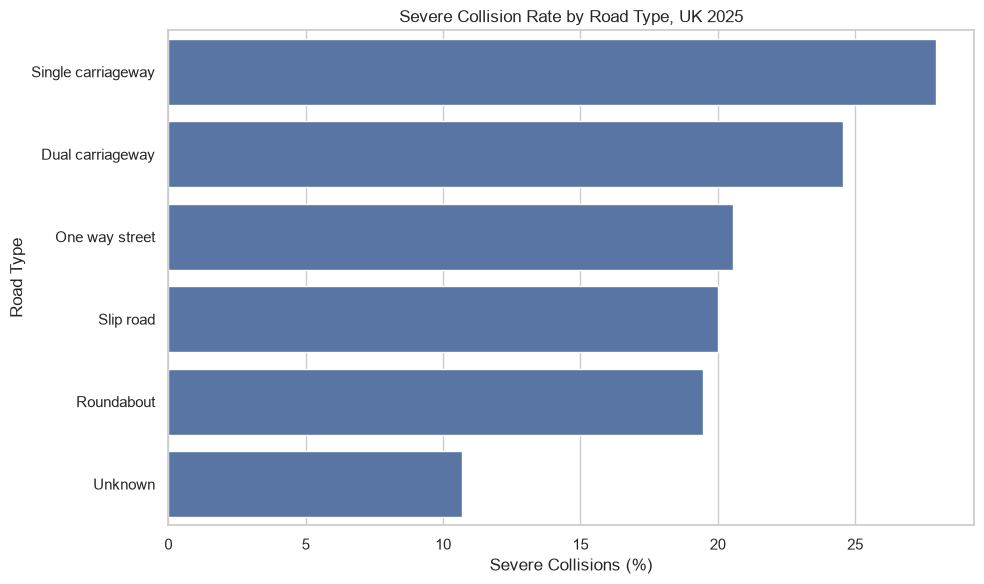

In [357]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=road_severity,
    x="severe_percentage",
    y="road_type_label"
)

plt.title("Severe Collision Rate by Road Type, UK 2025")
plt.xlabel("Severe Collisions (%)")
plt.ylabel("Road Type")

plt.tight_layout()
plt.show()

In [358]:
road_severity_table = pd.crosstab(
    df["road_type_label"],
    df["is_severe"]
)

chi2_road, p_road, dof_road, expected_road = chi2_contingency(
    road_severity_table
)

print("Road type vs severe collision")
print("Chi-square:", chi2_road)
print("Degrees of freedom:", dof_road)
print("p-value:", p_road)

Road type vs severe collision
Chi-square: 607.1314651092155
Degrees of freedom: 5
p-value: 5.820557286706426e-129


In [359]:
road_speed = pd.pivot_table(
    df, values="is_severe", index="road_type_label",
    columns="speed_limit", aggfunc="mean"
) * 100

road_speed_counts = pd.pivot_table(
    df, values="is_severe", index="road_type_label",
    columns="speed_limit", aggfunc="count"
)

# Exclude groups with fewer than 30 collisions to avoid interpreting unstable percentages
road_speed_reliable = road_speed.where(road_speed_counts >= 30)

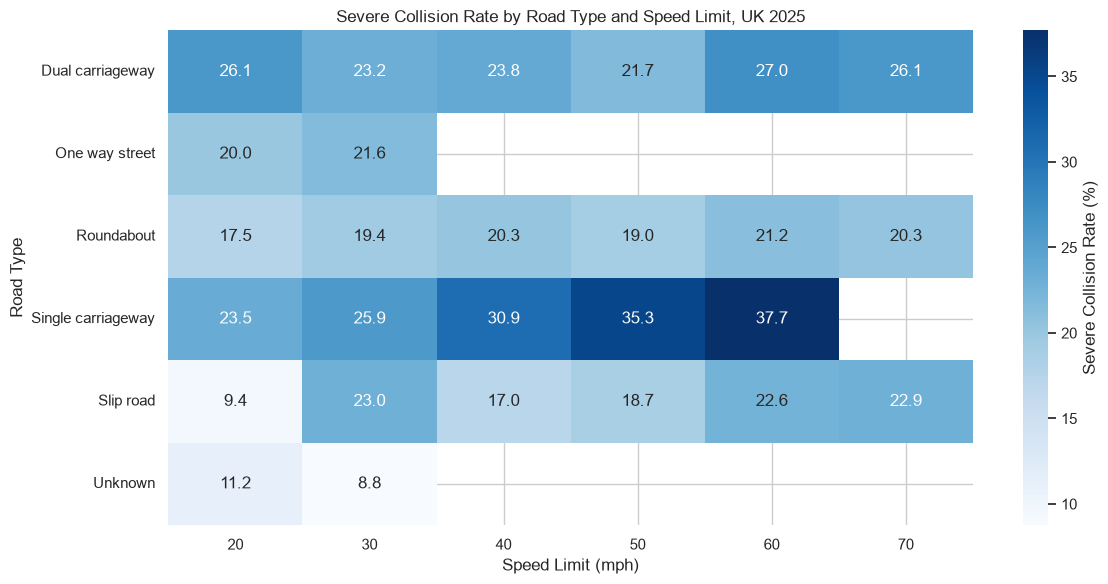

In [360]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    road_speed_reliable,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    cbar_kws={"label": "Severe Collision Rate (%)"}
)

plt.title(
    "Severe Collision Rate by Road Type and Speed Limit, UK 2025"
)
plt.xlabel("Speed Limit (mph)")
plt.ylabel("Road Type")

plt.tight_layout()
plt.show()

In [361]:
# Calculate Cramér's V to measure the strength of association
n = road_severity_table.to_numpy().sum()

cramers_v = np.sqrt(
    chi2_road / (
        n * min(
            road_severity_table.shape[0] - 1,
            road_severity_table.shape[1] - 1
        )
    )
)

print("Cramér's V:", round(cramers_v, 3))

Cramér's V: 0.077


### Q3 Findings

Road type was statistically associated with collision severity
(χ² = 607.13, df = 5, p < 0.001). Among known road types, single
carriageways had the highest severe-collision proportion at 27.93%,
while roundabouts had the lowest at 19.47%.

The combined road-type and speed-limit analysis showed the clearest
pattern for single carriageways. Their severe-collision rate increased
from 23.5% at 20 mph to 37.7% at 60 mph. Other road types showed less
consistent patterns across speed limits.

The association between road type and collision severity was small
overall, with Cramér's V approximately 0.077. Therefore, road type
alone does not explain most differences in collision severity.

Cells based on fewer than 30 collisions were excluded from the final
heatmap to avoid drawing conclusions from very small samples. These
results describe associations in reported collision data and do not
establish causation.

## 10. Limitations and Potential Bias

### 1. No traffic exposure data

The dataset contains reported collisions, but it does not tell us how
many vehicles were travelling at each hour, on each road type, or under
each speed limit. Therefore, a higher severe-collision percentage does
not necessarily mean that the underlying risk of driving is higher.

### 2. Association does not imply causation

The statistical tests identify associations between collision severity
and the variables examined. They do not prove that time of day, speed
limit, lighting or road type directly causes greater collision severity.

### 3. Potential confounding factors

Other variables may influence the observed relationships. These include
traffic volume, weather conditions, vehicle characteristics, road
location, road environment and driver behaviour. These factors were not
fully controlled for in the analysis.

### 4. Small groups

Some combinations of road type and speed limit contained relatively few
collisions. To reduce the risk of drawing conclusions from unstable
percentages, cells containing fewer than 30 collisions were excluded
from the final road-type and speed-limit heatmap.

### 5. Unknown and missing categories

Some records contain unknown or no-data values, particularly for
certain environmental variables. These records were retained where
appropriate but were excluded from specific comparisons when their
meaning or sample size could affect interpretation.

### 6. Limited time period

The analysis covers the 2025 dataset only. Therefore, the findings
describe patterns observed during 2025 and should not automatically be
generalised to other years or used to establish long-term trends.

### 7. Reported collision data

The dataset records reported road collisions rather than all road
incidents or near-misses. Consequently, the analysis reflects the
characteristics of recorded collisions.

## 11. Recommended Action

### Prioritise targeted safety measures on higher-speed single carriageways during high-severity periods

The analysis found that single carriageways had the highest severe-collision
proportion among known road types (27.93%). The road-type and speed-limit
analysis also showed an increase in severe-collision proportion on single
carriageways as the speed limit increased, reaching 37.7% at 60 mph.

The time-of-day analysis found that the proportion of severe collisions
was generally higher during late-night and early-morning hours.

Based on these findings, road-safety interventions should prioritise
higher-speed single-carriageway locations, particularly where collision
records indicate repeated severe outcomes during late-night and
early-morning periods. Potential measures could include targeted speed
management, improved lighting where appropriate, clearer road markings,
and additional safety assessment of high-risk locations.

This recommendation should be treated as a prioritisation strategy
rather than evidence that speed limits or lighting directly cause
severe collisions. Further analysis using traffic-volume and location
data would be needed before selecting specific interventions.

## 12. Executive Summary

### Three Key Takeaways

1. **Collision severity varies by time of day.**  
   Severe collisions represented a larger proportion of reported
   collisions during late-night and early-morning hours. The highest
   observed severe-collision rate was 33.12% at 04:00, compared with
   21.37% at 08:00. The chi-square test showed a statistically
   significant association between hour of day and severe collision
   status (χ² = 318.78, df = 23, p < 0.001).

2. **Speed limit and lighting conditions are associated with severity.**  
   The highest overall severe-collision rate among speed-limit
   categories was observed at 60 mph (36.38%). Several combinations
   of higher speed limits and darkness conditions also showed relatively
   high severe-collision proportions. Both speed limit and lighting
   conditions were statistically associated with severe collision
   status (p < 0.001).

3. **Single carriageways show the highest severe-collision proportion
   among known road types.**  
   Single carriageways had a severe-collision rate of 27.93%, compared
   with 19.47% for roundabouts. The association between road type and
   severe collision status was statistically significant, although the
   Cramér's V of approximately 0.077 indicates a small overall
   association.

### Recommended Action

Road-safety planning should prioritise **higher-speed single-carriageway
locations**, particularly locations with repeated severe collisions
during late-night and early-morning periods. Possible interventions
include targeted speed management, improved lighting where appropriate,
clearer road markings and detailed safety assessments of high-risk
locations.

These findings describe associations in reported 2025 UK collision
data and should not be interpreted as causal effects. Traffic exposure,
location, weather, vehicle characteristics and other factors should be
considered before implementing specific interventions.